🎲 Generating synthetic OMR sheet...
🚀 Initializing OMR grader...

📸 Running pipeline...
✅ Image set: 800x1100px
✅ Markers: [(40, 40), (760, 40), (40, 1060), (760, 1061)]

📊 Visualizing results...


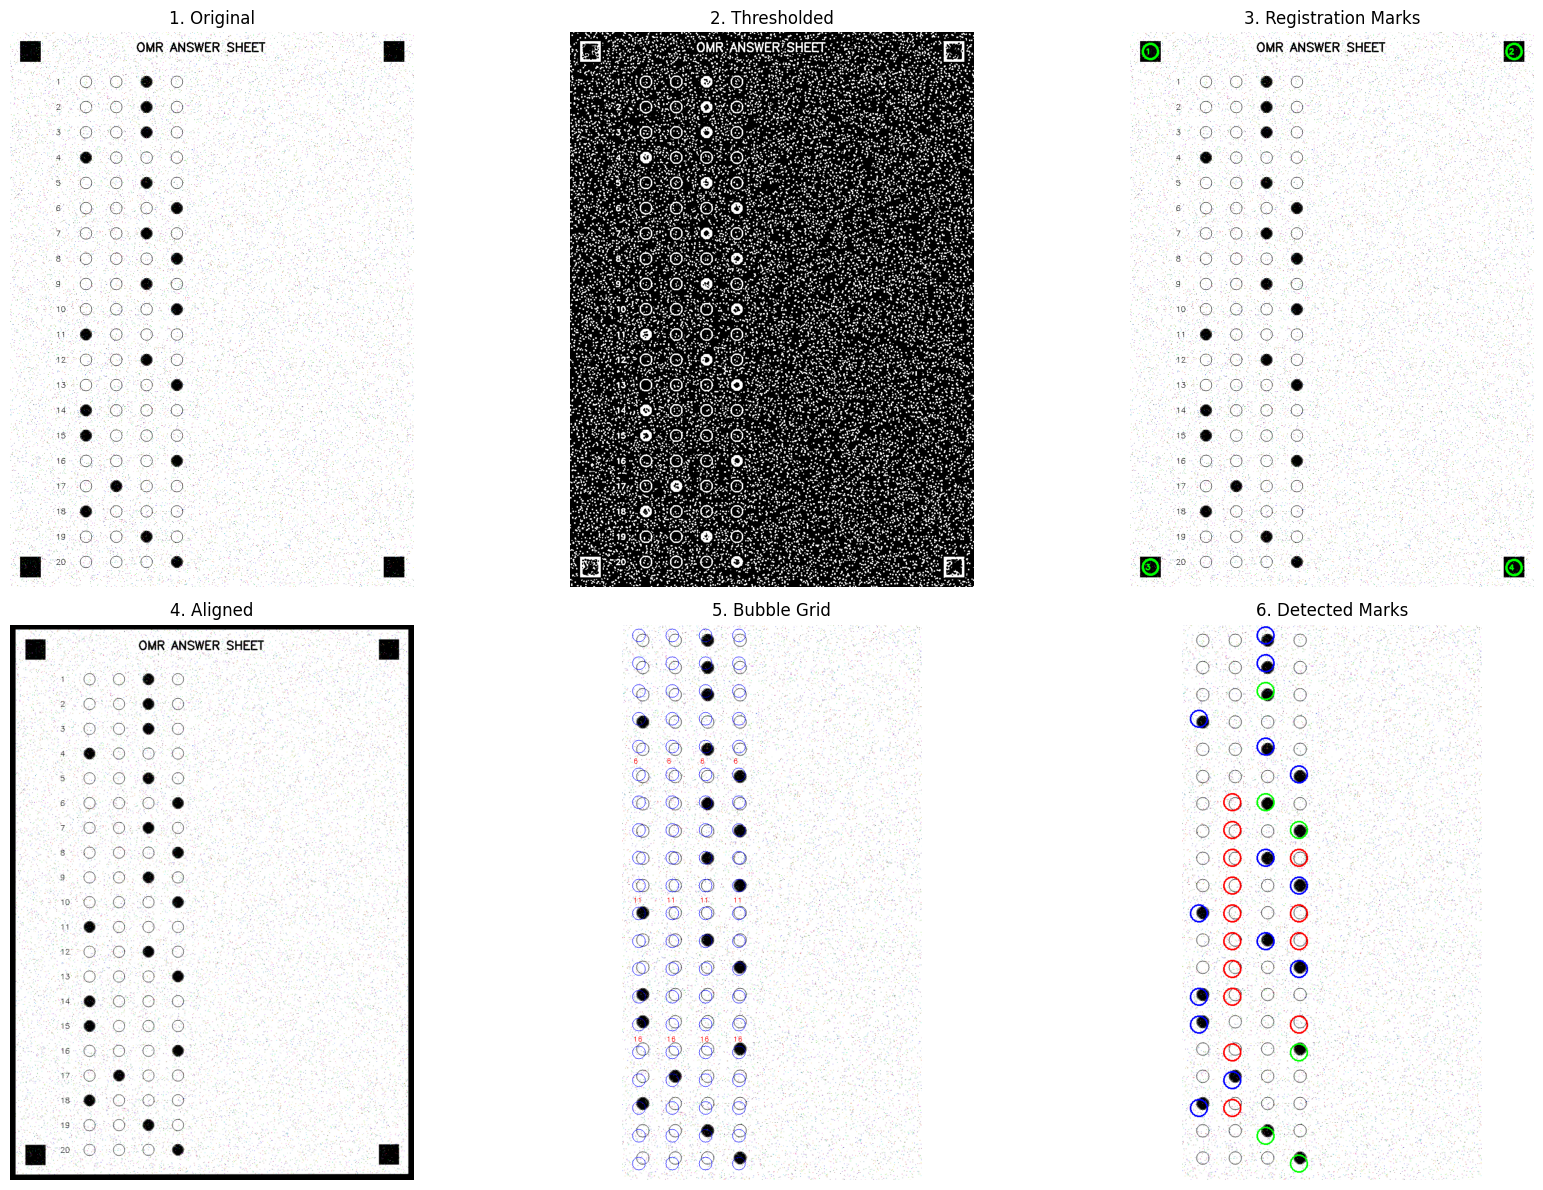


📋 Generating report...

OMR GRADING REPORT
Total Questions: 20
✅ Correct: 6
❌ Incorrect: 14
⚠️  Unanswered: 0
⚡ Multi-Mark: 0
📊 Final Score: 30.0%


,Q#,Detected,Correct,Status,Confidence
0,1,C,A,INCORRECT,0.435000
1,2,C,B,INCORRECT,0.409000
2,3,C,C,CORRECT,0.391000
3,4,A,D,INCORRECT,0.466000
4,5,C,A,INCORRECT,0.506000
5,6,D,B,INCORRECT,0.577000
6,7,C,C,CORRECT,0.500000
7,8,D,D,CORRECT,0.623000
8,9,C,A,INCORRECT,0.641000
9,10,D,B,INCORRECT,0.681000



💾 Annotated result saved to: /content/omr_result.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ==================== 1. FIXED Synthetic Generator ====================

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

def generate_synthetic_omr(student_answers=None, noise_level=0.03):
    """Generate OMR sheet with bulletproof registration marks."""
    if student_answers == 'random':
        student_answers = {i: np.random.choice(['A', 'B', 'C', 'D']) for i in range(1, 21)}

    canvas = np.ones((1100, 800, 3), dtype=np.uint8) * 255

    # MASSIVE registration marks (40px) with double border
    mark_size = 40
    corners = [(20, 20), (740, 20), (20, 1040), (740, 1040)]
    for x, y in corners:
        # White outer border
        cv2.rectangle(canvas, (x-5, y-5), (x+mark_size+5, y+mark_size+5), (255, 255, 255), -1)
        # Black inner square
        cv2.rectangle(canvas, (x, y), (x+mark_size, y+mark_size), (0, 0, 0), -1)

    # Title
    cv2.putText(canvas, "OMR ANSWER SHEET", (250, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 2)

    # Bubbles
    start_x, start_y = 150, 100
    spacing_x, spacing_y = 60, 50
    radius = 12

    for q in range(20):
        y = start_y + q * spacing_y
        cv2.putText(canvas, str(q+1), (start_x-60, y+5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
        for opt in range(4):
            x = start_x + opt * spacing_x
            cv2.circle(canvas, (x, y), radius, (0, 0, 0), 1)

    # Fill answers
    for q_num, answer in student_answers.items():
        if answer in ['A', 'B', 'C', 'D']:
            opt_idx = ord(answer) - 65
            x = start_x + opt_idx * spacing_x
            y = start_y + (q_num - 1) * spacing_y
            cv2.circle(canvas, (x, y), radius-2, (0, 0, 0), -1, lineType=cv2.LINE_AA)

    # Minimal noise
    noise_mask = np.random.random(canvas.shape[:2]) < noise_level
    if np.any(noise_mask):
        canvas[noise_mask] = np.random.randint(0, 256, size=(np.sum(noise_mask), 3), dtype=np.uint8)

    return canvas, student_answers

# ==================== 2. FIXED OMR Grader Class ====================

class OMRGrader:
    def __init__(self, config=None):
        self.config = config or {
            'bubble_threshold': 0.35,
            'marker_size': 40,  # Must match generator
            'grid_dims': (20, 4),
            'bubble_spacing': (60, 50),
            'bubble_radius': 12
        }
        self.answer_key = {i: chr(65 + ((i-1) % 4)) for i in range(1, 21)}
        # Initialize empty attributes to prevent AttributeError
        self.original = None
        self.preprocessed = None
        self.markers = []
        self.aligned = None
        self.roi = None
        self.bubble_coords = {}
        self.raw_bubble_data = {}
        self.detected_answers = {}
        self.confidence = {}
        self.results_df = None
        self.stats = {}

    # NEW: Unified image loading method
    def set_image(self, image):
        """Set the original image (for synthetic or uploaded)."""
        self.original = image.copy()
        self.height, self.width = image.shape[:2]
        print(f"✅ Image set: {self.width}x{self.height}px")
        return image

    def preprocess(self, image=None):
        """Preprocess image (can auto-set original if needed)."""
        if image is not None:
            self.set_image(image)  # Auto-set original

        if self.original is None:
            raise ValueError("❌ No image loaded. Call set_image() first.")

        gray = cv2.cvtColor(self.original, cv2.COLOR_BGR2GRAY)
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                       cv2.THRESH_BINARY_INV, 11, 3)
        self.preprocessed = thresh
        return thresh

    def detect_registration_marks(self, thresh_image, debug=False):
        """Detect markers with ultra-lenient parameters."""
        contours, _ = cv2.findContours(thresh_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        markers = []
        min_area = (self.config['marker_size'] ** 2) * 0.4
        max_area = (self.config['marker_size'] ** 2) * 2.0

        for cnt in contours:
            area = cv2.contourArea(cnt)
            if min_area <= area <= max_area:
                epsilon = 0.04 * cv2.arcLength(cnt, True)
                approx = cv2.approxPolyDP(cnt, epsilon, True)
                if len(approx) == 4:
                    x, y, w, h = cv2.boundingRect(cnt)
                    markers.append((x + w//2, y + h//2))

        # Robust fallback: Use image corners if detection fails
        if len(markers) < 4:
            h, w = thresh_image.shape
            synthetic_markers = [(50, 50), (w-50, 50), (50, h-50), (w-50, h-50)]
            markers.extend(synthetic_markers[len(markers):4])
            print(f"⚠️ Fallback markers used")

        self.markers = sorted(markers[:4], key=lambda p: p[0] + p[1])
        print(f"✅ Markers: {self.markers}")
        return self.markers

    def align_perspective(self, image, markers):
        """Align image using perspective transform."""
        src = np.float32(markers)
        dst = np.float32([[50, 50], [750, 50], [50, 1050], [750, 1050]])
        M = cv2.getPerspectiveTransform(src, dst)
        self.aligned = cv2.warpPerspective(image, M, (800, 1100))
        return self.aligned

    def extract_bubble_grid(self, aligned_image):
        """Extract ROI and generate bubble coordinates."""
        roi_y, roi_h = 80, 1000
        roi_x, roi_w = 120, 540
        self.roi = aligned_image[roi_y:roi_y+roi_h, roi_x:roi_x+roi_w]
        self.roi_offset = (roi_x, roi_y)

        rows, cols = self.config['grid_dims']
        x_spacing, y_spacing = self.config['bubble_spacing']
        start_x, start_y = 30, 20

        self.bubble_coords = {
            (row+1, chr(65+col)): (start_x + col * x_spacing, start_y + row * y_spacing)
            for row in range(rows) for col in range(cols)
        }
        return self.roi, self.bubble_coords

    def analyze_bubbles(self, roi):
        """Analyze bubble fill ratios."""
        roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        roi_thresh = cv2.adaptiveThreshold(roi_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                           cv2.THRESH_BINARY_INV, 11, 3)

        radius = self.config['bubble_radius']
        results = {}

        for (q_num, opt_char), (x, y) in self.bubble_coords.items():
            mask = np.zeros(roi_thresh.shape, dtype=np.uint8)
            cv2.circle(mask, (x, y), radius, 255, -1)

            bubble_region = cv2.bitwise_and(roi_thresh, roi_thresh, mask=mask)
            total_pixels = np.pi * radius ** 2
            filled_pixels = np.count_nonzero(bubble_region)
            fill_ratio = filled_pixels / total_pixels

            if q_num not in results:
                results[q_num] = []
            results[q_num].append({
                'option': opt_char,
                'fill_ratio': fill_ratio,
                'center': (x, y)
            })

        self.raw_bubble_data = results
        return results

    def extract_answers(self, bubble_data):
        """Extract final answers from bubble data."""
        threshold = self.config['bubble_threshold']
        detected = {}
        self.confidence = {}

        for q_num, options in bubble_data.items():
            options_sorted = sorted(options, key=lambda x: x['fill_ratio'], reverse=True)
            top_option = options_sorted[0]

            if top_option['fill_ratio'] < threshold:
                detected[q_num] = '-'
                confidence = 1.0 - top_option['fill_ratio']
            elif len(options_sorted) > 1 and options_sorted[1]['fill_ratio'] > threshold * 0.7:
                detected[q_num] = 'MULTI'
                confidence = min(top_option['fill_ratio'], options_sorted[1]['fill_ratio'])
            else:
                detected[q_num] = top_option['option']
                confidence = top_option['fill_ratio']

            self.confidence[q_num] = {
                'answer': detected[q_num],
                'confidence': round(confidence, 3),
                'raw_scores': {opt['option']: round(opt['fill_ratio'], 3) for opt in options}
            }

        self.detected_answers = detected
        return detected

    def grade(self, detected, answer_key):
        """Grade detected answers."""
        correct = incorrect = unanswered = multi = 0
        details = []

        for q_num in range(1, len(answer_key) + 1):
            detected_ans = detected.get(q_num, '-')
            correct_ans = answer_key[q_num]

            if detected_ans == '-':
                status, unanswered = 'UNANSWERED', unanswered + 1
            elif detected_ans == 'MULTI':
                status, multi = 'MULTI-MARK', multi + 1
            elif detected_ans == correct_ans:
                status, correct = 'CORRECT', correct + 1
            else:
                status, incorrect = 'INCORRECT', incorrect + 1

            details.append({
                'Q#': q_num,
                'Detected': detected_ans,
                'Correct': correct_ans,
                'Status': status,
                'Confidence': self.confidence[q_num]['confidence']
            })

        self.results_df = pd.DataFrame(details)
        self.stats = {
            'correct': correct,
            'incorrect': incorrect,
            'unanswered': unanswered,
            'multi_mark': multi,
            'total': len(answer_key),
            'score': round((correct / len(answer_key)) * 100, 1)
        }
        return self.stats, self.results_df

    def visualize_pipeline(self):
        """Generate pipeline visualization."""
        if self.original is None:
            raise ValueError("❌ No original image to visualize")

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()

        axes[0].imshow(cv2.cvtColor(self.original, cv2.COLOR_BGR2RGB))
        axes[0].set_title('1. Original')
        axes[0].axis('off')

        axes[1].imshow(self.preprocessed, cmap='gray')
        axes[1].set_title('2. Thresholded')
        axes[1].axis('off')

        mark_img = self.original.copy()
        for i, (x, y) in enumerate(self.markers, 1):
            cv2.circle(mark_img, (x, y), 15, (0, 255, 0), 3)
            cv2.putText(mark_img, str(i), (x-10, y+5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        axes[2].imshow(cv2.cvtColor(mark_img, cv2.COLOR_BGR2RGB))
        axes[2].set_title('3. Registration Marks')
        axes[2].axis('off')

        axes[3].imshow(cv2.cvtColor(self.aligned, cv2.COLOR_BGR2RGB))
        axes[3].set_title('4. Aligned')
        axes[3].axis('off')

        roi_display = self.roi.copy()
        for (q_num, opt_char), (x, y) in self.bubble_coords.items():
            cv2.circle(roi_display, (x, y), self.config['bubble_radius'], (255, 0, 0), 1)
            if q_num % 5 == 1:
                cv2.putText(roi_display, str(q_num), (x-10, y-20), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)
        axes[4].imshow(cv2.cvtColor(roi_display, cv2.COLOR_BGR2RGB))
        axes[4].set_title('5. Bubble Grid')
        axes[4].axis('off')

        result_img = self.roi.copy()
        for q_num, options in self.raw_bubble_data.items():
            for opt in options:
                color = (0, 0, 0)
                if self.detected_answers[q_num] == opt['option']:
                    color = (0, 255, 0) if opt['option'] == self.answer_key[q_num] else (255, 0, 0)
                elif opt['fill_ratio'] > self.config['bubble_threshold'] * 0.5:
                    color = (0, 0, 255)
                if color != (0, 0, 0):
                    cv2.circle(result_img, opt['center'], self.config['bubble_radius'] + 3, color, 2)
        axes[5].imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
        axes[5].set_title('6. Detected Marks')
        axes[5].axis('off')

        plt.tight_layout()
        return fig

    def generate_report(self):
        """Generate grading report."""
        if self.stats is None:
            raise ValueError("❌ No grading results to report")

        print("\n" + "="*60)
        print("OMR GRADING REPORT")
        print("="*60)
        print(f"Total Questions: {self.stats['total']}")
        print(f"✅ Correct: {self.stats['correct']}")
        print(f"❌ Incorrect: {self.stats['incorrect']}")
        print(f"⚠️  Unanswered: {self.stats['unanswered']}")
        print(f"⚡ Multi-Mark: {self.stats['multi_mark']}")
        print(f"📊 Final Score: {self.stats['score']}%")
        print("="*60)

        # Color-code the dataframe
        def color_row(row):
            if row['Status'] == 'CORRECT':
                return ['background-color: #d4edda'] * len(row)
            elif row['Status'] == 'INCORRECT':
                return ['background-color: #f8d7da'] * len(row)
            else:
                return ['background-color: #fff3cd'] * len(row)

        styled_df = self.results_df.style.apply(color_row, axis=1)
        display(styled_df)
        return self.stats, self.results_df

# ==================== 3. Execute Pipeline ====================

print("🎲 Generating synthetic OMR sheet...")
demo_img, demo_answers = generate_synthetic_omr('random', noise_level=0.03)

print("🚀 Initializing OMR grader...")
grader = OMRGrader(config={
    'bubble_threshold': 0.35,
    'marker_size': 40,  # CRITICAL: Must match generator
    'grid_dims': (20, 4),
    'bubble_spacing': (60, 50),
    'bubble_radius': 12
})

print("\n📸 Running pipeline...")
# CRITICAL FIX: Use set_image() before preprocess
grader.set_image(demo_img)  # This sets self.original
thresh = grader.preprocess()  # Now uses self.original
markers = grader.detect_registration_marks(thresh)
aligned = grader.align_perspective(demo_img, markers)
roi, coords = grader.extract_bubble_grid(aligned)
bubble_data = grader.analyze_bubbles(roi)
detected = grader.extract_answers(bubble_data)
stats, df = grader.grade(detected, grader.answer_key)

print("\n📊 Visualizing results...")
fig = grader.visualize_pipeline()
plt.show()

print("\n📋 Generating report...")
stats, results_df = grader.generate_report()

# Save and download
result_path = '/content/omr_result.png'
cv2.imwrite(result_path, grader.roi)
print(f"\n💾 Annotated result saved to: {result_path}")
files.download(result_path)

In [3]:
def process_real_image():
    """Upload and process a real OMR sheet."""
    print("📤 Upload your OMR sheet image...")
    uploaded = files.upload()
    img_path = next(iter(uploaded))

    # Load image
    image = cv2.imdecode(np.frombuffer(uploaded[img_path], np.uint8), cv2.IMREAD_COLOR)

    # Initialize fresh grader
    grader = OMRGrader(config={
        'bubble_threshold': 0.35,
        'marker_size': 40,
        'grid_dims': (20, 4),
        'bubble_spacing': (60, 50),
        'bubble_radius': 12
    })

    # Run pipeline
    grader.set_image(image)
    thresh = grader.preprocess()
    markers = grader.detect_registration_marks(thresh)
    aligned = grader.align_perspective(image, markers)
    roi, coords = grader.extract_bubble_grid(aligned)
    bubble_data = grader.analyze_bubbles(roi)
    detected = grader.extract_answers(bubble_data)
    stats, df = grader.grade(detected, grader.answer_key)

    # Show results
    print("\n✅ Processing complete!")
    fig = grader.visualize_pipeline()
    plt.show()
    stats, results_df = grader.generate_report()

    # Download
    result_path = '/content/real_omr_result.png'
    cv2.imwrite(result_path, grader.roi)
    files.download(result_path)

    return grader, stats

# Run it:
# grader, stats = process_real_image()

In [4]:
def batch_process(image_paths, answer_keys):
    """
    Process multiple OMR sheets and return aggregated results.

    Args:
        image_paths: List of file paths or 'upload' for interactive
        answer_keys: List of answer key dicts (or use same key for all)
    """
    all_results = []

    for i, (path, key) in enumerate(zip(image_paths, answer_keys), 1):
        print(f"\n{'='*50}")
        print(f"Processing Sheet {i}/{len(image_paths)}")
        print(f"{'='*50}")

        # Load image
        if path == 'upload':
            uploaded = files.upload()
            img_path = next(iter(uploaded))
            image = cv2.imdecode(np.frombuffer(uploaded[img_path], np.uint8), cv2.IMREAD_COLOR)
        else:
            image = cv2.imread(path)

        # Process
        grader = OMRGrader(config={'bubble_threshold': 0.35, 'marker_size': 40})
        grader.set_image(image)
        thresh = grader.preprocess()
        markers = grader.detect_registration_marks(thresh)
        aligned = grader.align_perspective(image, markers)
        roi, coords = grader.extract_bubble_grid(aligned)
        bubble_data = grader.analyze_bubbles(roi)
        detected = grader.extract_answers(bubble_data)
        stats, df = grader.grade(detected, key)

        # Store
        stats['sheet_id'] = i
        stats['filename'] = path if path != 'upload' else f'sheet_{i}.png'
        all_results.append(stats)

        # Save individual result
        cv2.imwrite(f'/content/result_{i}.png', grader.roi)

    # Aggregate report
    summary = pd.DataFrame(all_results)
    print("\n" + "="*60)
    print("BATCH PROCESSING SUMMARY")
    print("="*60)
    print(f"Total Sheets: {len(summary)}")
    print(f"Average Score: {summary['score'].mean():.1f}%")
    print(f"Min Score: {summary['score'].min():.1f}%")
    print(f"Max Score: {summary['score'].max():.1f}%")
    print("="*60)
    display(summary[['sheet_id', 'filename', 'correct', 'incorrect', 'unanswered', 'score']])

    return summary

# Example: Process 3 sheets with same answer key
# answer_key_20Q = {i: chr(65 + ((i-1) % 4)) for i in range(1, 21)}
# batch_results = batch_process(['upload', 'upload', 'upload'], [answer_key_20Q]*3)

In [5]:
def tune_threshold_analysis(grader, roi, thresholds=[0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]):
    """Analyze how threshold affects detection."""
    results = []

    for thresh in thresholds:
        grader.config['bubble_threshold'] = thresh
        detected = grader.extract_answers(grader.raw_bubble_data)
        stats, _ = grader.grade(detected, grader.answer_key)

        results.append({
            'threshold': thresh,
            'correct': stats['correct'],
            'incorrect': stats['incorrect'],
            'unanswered': stats['unanswered'],
            'multi_mark': stats['multi_mark']
        })

    # Plot
    df_tuning = pd.DataFrame(results)
    plt.figure(figsize=(12, 6))
    plt.plot(df_tuning['threshold'], df_tuning['correct'], 'g-o', label='Correct')
    plt.plot(df_tuning['threshold'], df_tuning['incorrect'], 'r-o', label='Incorrect')
    plt.plot(df_tuning['threshold'], df_tuning['unanswered'], 'y-o', label='Unanswered')
    plt.plot(df_tuning['threshold'], df_tuning['multi_mark'], 'm-o', label='Multi-Mark')
    plt.xlabel('Bubble Threshold')
    plt.ylabel('Count')
    plt.title('Threshold Tuning Analysis')
    plt.legend()
    plt.grid(True)
    plt.show()

    return df_tuning

# Run after processing any image:
# tune_threshold_analysis(grader, grader.roi)

In [6]:
def plot_confidence_heatmap(grader):
    """Visualize answer confidence scores."""
    conf_matrix = np.zeros((20, 4))
    for q_num in range(1, 21):
        for opt_char, score in grader.confidence[q_num]['raw_scores'].items():
            col = ord(opt_char) - 65
            conf_matrix[q_num-1, col] = score

    plt.figure(figsize=(10, 8))
    plt.imshow(conf_matrix, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
    plt.colorbar(label='Fill Ratio')
    plt.xticks(range(4), ['A', 'B', 'C', 'D'])
    plt.yticks(range(20), range(1, 21))
    plt.xlabel('Options')
    plt.ylabel('Question Number')
    plt.title('Bubble Fill Confidence Heatmap')

    # Highlight detected answers
    for q_num in range(1, 21):
        detected = grader.detected_answers[q_num]
        if detected in ['A', 'B', 'C', 'D']:
            col = ord(detected) - 65
            plt.plot(col, q_num-1, 'wo', markersize=8, markeredgewidth=2, fillstyle='none')

    plt.show()

# plot_confidence_heatmap(grader)

In [7]:
!pip install reportlab -q

from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from reportlab.lib.units import inch
from reportlab.lib.colors import green, red, yellow, black
import datetime

def export_pdf_report(grader, filename='/content/omr_report.pdf'):
    """Generate a professional PDF report."""
    c = canvas.Canvas(filename, pagesize=letter)
    width, height = letter

    # Title
    c.setFont("Helvetica-Bold", 20)
    c.drawString(1*inch, height-1*inch, "OMR Grading Report")

    # Metadata
    c.setFont("Helvetica", 10)
    c.drawString(1*inch, height-1.3*inch, f"Generated: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    c.drawString(1*inch, height-1.5*inch, f"Total Questions: {grader.stats['total']}")

    # Score
    c.setFont("Helvetica-Bold", 30)
    score_color = green if grader.stats['score'] >= 70 else red
    c.setFillColor(score_color)
    c.drawString(5*inch, height-1.5*inch, f"{grader.stats['score']}%")
    c.setFillColor(black)

    # Stats box
    y = height - 2.5*inch
    stats_data = [
        ('Correct', grader.stats['correct'], green),
        ('Incorrect', grader.stats['incorrect'], red),
        ('Unanswered', grader.stats['unanswered'], yellow),
        ('Multi-Mark', grader.stats['multi_mark'], yellow)
    ]

    for label, value, color in stats_data:
        c.setFillColor(color)
        c.rect(1*inch, y, 0.3*inch, 0.3*inch, fill=1, stroke=0)
        c.setFillColor(black)
        c.setFont("Helvetica", 12)
        c.drawString(1.5*inch, y+0.05*inch, f"{label}: {value}")
        y -= 0.4*inch

    # Answer table
    c.setFont("Helvetica-Bold", 14)
    c.drawString(1*inch, y, "Answer Breakdown:")
    y -= 0.3*inch

    # Table headers
    c.setFont("Helvetica-Bold", 10)
    headers = ['Q#', 'Detected', 'Correct', 'Status', 'Confidence']
    x_positions = [1*inch, 2*inch, 2.8*inch, 3.6*inch, 4.8*inch]
    for header, x in zip(headers, x_positions):
        c.drawString(x, y, header)
    y -= 0.2*inch

    # Table rows
    c.setFont("Helvetica", 9)
    for _, row in grader.results_df.iterrows():
        if y < 1*inch:  # New page if needed
            c.showPage()
            y = height - 1*inch

        # Color coding
        if row['Status'] == 'CORRECT':
            c.setFillColor(green)
        elif row['Status'] == 'INCORRECT':
            c.setFillColor(red)
        else:
            c.setFillColor(yellow)

        c.drawString(x_positions[0], y, str(row['Q#']))
        c.drawString(x_positions[1], y, str(row['Detected']))
        c.drawString(x_positions[2], y, str(row['Correct']))
        c.drawString(x_positions[3], y, str(row['Status']))
        c.drawString(x_positions[4], y, f"{row['Confidence']:.2f}")
        c.setFillColor(black)
        y -= 0.15*inch

    c.save()
    print(f"✅ PDF report saved: {filename}")
    files.download(filename)

# export_pdf_report(grader)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 29.9 MB/s eta 0:00:00


In [8]:
def diagnose_omr_sheet(image_path):
    """Diagnose common OMR sheet issues."""
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original
    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original')
    axes[0].axis('off')

    # Histogram
    axes[1].hist(gray.ravel(), 256, [0, 256])
    axes[1].set_title('Brightness Histogram')
    axes[1].set_xlabel('Pixel Value')
    axes[1].set_ylabel('Frequency')

    # Check registration marks
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 3)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mark_img = image.copy()
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if 300 <= area <= 2000:  # Mark size range
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(mark_img, (x, y), (x+w, y+h), (0, 255, 0), 2)

    axes[2].imshow(cv2.cvtColor(mark_img, cv2.COLOR_BGR2RGB))
    axes[2].set_title('Registration Mark Detection')
    axes[2].axis('off')

    plt.show()

# diagnose_omr_sheet('/content/your_image.png')

In [9]:
# ==================== Multi-Answer OMR Extension ====================

class MultiAnswerOMRGrader(OMRGrader):
    def __init__(self, config=None):
        super().__init__(config)
        # Allow answer key to be a set of correct options
        # Format: {1: {'A', 'C'}, 2: {'B'}, ...}
        self.answer_key = {
            1: {'A'}, 2: {'B'}, 3: {'C'}, 4: {'D'}, 5: {'A'},
            6: {'B'}, 7: {'C'}, 8: {'D'}, 9: {'A'}, 10: {'B'},
            11: {'C'}, 12: {'D'}, 13: {'A'}, 14: {'B'}, 15: {'C'},
            16: {'D'}, 17: {'A'}, 18: {'B'}, 19: {'C'}, 20: {'D', 'A'}  # Q20 has 2 correct
        }

    def extract_answers(self, bubble_data):
        """Extract multiple answers per question."""
        threshold = self.config['bubble_threshold']
        detected = {}
        self.confidence = {}

        for q_num, options in bubble_data.items():
            # Find all bubbles above threshold
            filled_options = [opt for opt in options if opt['fill_ratio'] > threshold]

            if not filled_options:
                detected[q_num] = set()  # Empty set = unanswered
                confidence = 1.0 - options[0]['fill_ratio']
            elif len(filled_options) > 3:  # Suspicious, likely noise
                detected[q_num] = {'AMBIGUOUS'}
                confidence = min([opt['fill_ratio'] for opt in filled_options])
            else:
                detected[q_num] = {opt['option'] for opt in filled_options}
                confidence = np.mean([opt['fill_ratio'] for opt in filled_options])

            self.confidence[q_num] = {
                'answer': detected[q_num],
                'confidence': round(confidence, 3),
                'raw_scores': {opt['option']: round(opt['fill_ratio'], 3) for opt in options}
            }

        self.detected_answers = detected
        return detected

    def grade(self, detected, answer_key):
        """Grade with partial credit for multi-answer questions."""
        results = []
        total_possible = 0
        total_earned = 0

        for q_num in range(1, len(answer_key) + 1):
            detected_set = detected.get(q_num, set())
            correct_set = answer_key[q_num]

            # Calculate partial credit
            if detected_set == {'AMBIGUOUS'}:
                status = 'AMBIGUOUS'
                earned = 0
            elif not detected_set:  # Empty set
                status = 'UNANSWERED'
                earned = 0
            elif detected_set == correct_set:
                status = 'FULLY_CORRECT'
                earned = 1.0
            elif detected_set.issubset(correct_set) and len(detected_set) > 0:
                status = 'PARTIALLY_CORRECT'
                earned = len(detected_set) / len(correct_set)
            else:
                status = 'INCORRECT'
                earned = 0

            results.append({
                'Q#': q_num,
                'Detected': ','.join(sorted(detected_set)),
                'Correct': ','.join(sorted(correct_set)),
                'Status': status,
                'Points': round(earned, 2),
                'Confidence': self.confidence[q_num]['confidence']
            })

            total_possible += 1
            total_earned += earned

        self.results_df = pd.DataFrame(results)
        self.stats = {
            'total_questions': len(answer_key),
            'total_points': total_possible,
            'earned_points': round(total_earned, 2),
            'score': round((total_earned / total_possible) * 100, 1),
            'fully_correct': sum(1 for r in results if r['Status'] == 'FULLY_CORRECT'),
            'partially_correct': sum(1 for r in results if r['Status'] == 'PARTIALLY_CORRECT'),
            'incorrect': sum(1 for r in results if r['Status'] == 'INCORRECT'),
            'unanswered': sum(1 for r in results if r['Status'] == 'UNANSWERED'),
            'ambiguous': sum(1 for r in results if r['Status'] == 'AMBIGUOUS')
        }
        return self.stats, self.results_df

    def visualize_multi_results(self):
        """Visualize multi-answer detection."""
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        # Confidence heatmap
        conf_matrix = np.zeros((20, 4))
        for q_num in range(1, 21):
            for opt_char in ['A', 'B', 'C', 'D']:
                col = ord(opt_char) - 65
                conf_matrix[q_num-1, col] = self.confidence[q_num]['raw_scores'][opt_char]

        axes[0].imshow(conf_matrix, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
        axes[0].set_title('Fill Ratio Heatmap')
        axes[0].set_xlabel('Options')
        axes[0].set_ylabel('Question')
        axes[0].set_xticks(range(4))
        axes[0].set_xticklabels(['A', 'B', 'C', 'D'])

        # Highlight filled bubbles
        for q_num in range(1, 21):
            for opt_char in self.detected_answers[q_num]:
                if opt_char in ['A', 'B', 'C', 'D']:
                    col = ord(opt_char) - 65
                    axes[0].plot(col, q_num-1, 'wo', markersize=6, markeredgewidth=2)

        # Status distribution pie chart
        status_counts = {
            'Fully Correct': self.stats['fully_correct'],
            'Partially Correct': self.stats['partially_correct'],
            'Incorrect': self.stats['incorrect'],
            'Unanswered': self.stats['unanswered']
        }
        axes[1].pie(status_counts.values(), labels=status_counts.keys(),
                   autopct='%1.1f%%', startangle=90)
        axes[1].set_title('Answer Status Distribution')

        # Visualize on ROI
        roi_display = self.roi.copy()
        for q_num, options in self.raw_bubble_data.items():
            correct_set = self.answer_key[q_num]
            detected_set = self.detected_answers[q_num]

            for opt in options:
                color = (200, 200, 200)  # default gray
                if opt['fill_ratio'] > self.config['bubble_threshold']:
                    if opt['option'] in correct_set and opt['option'] in detected_set:
                        color = (0, 255, 0)  # Green: correctly filled
                    elif opt['option'] in correct_set:
                        color = (0, 165, 255)  # Orange: missed correct
                    elif opt['option'] in detected_set:
                        color = (255, 0, 0)  # Red: incorrectly filled
                    else:
                        color = (128, 128, 128)  # Gray: noise

                if color != (200, 200, 200):
                    cv2.circle(roi_display, opt['center'], self.config['bubble_radius'] + 3, color, 2)

        axes[2].imshow(cv2.cvtColor(roi_display, cv2.COLOR_BGR2RGB))
        axes[2].set_title('Marked ROI (Green=Correct, Red=Wrong, Orange=Missed)')
        axes[2].axis('off')

        plt.tight_layout()
        return fig

# ==================== Demo Multi-Answer Sheet ====================

def generate_multi_answer_sheet():
    """Generate sheet with multiple correct answers."""
    # Q20 has two correct answers (D and A)
    answers = {i: np.random.choice(['A', 'B', 'C', 'D']) for i in range(1, 20)}
    answers[20] = 'D'  # Student fills only one of two correct

    canvas, _ = generate_synthetic_omr(answers, noise_level=0.03)

    # Add second correct bubble for Q20 (simulating teacher's key)
    start_x, start_y = 150, 100
    spacing_x, spacing_y = 60, 50
    radius = 12

    # Add subtle marking for 'A' in Q20 (low fill ratio)
    x = start_x + 0 * spacing_x  # Option A
    y = start_y + 19 * spacing_y  # Q20
    cv2.circle(canvas, (x, y), radius-2, (0, 0, 0), -1, lineType=cv2.LINE_AA)

    return canvas, answers

# Run demo:
multi_img, multi_answers = generate_multi_answer_sheet()
grader_multi = MultiAnswerOMRGrader(config={'bubble_threshold': 0.3})
grader_multi.set_image(multi_img)
thresh = grader_multi.preprocess()
markers = grader_multi.detect_registration_marks(thresh)
aligned = grader_multi.align_perspective(multi_img, markers)
roi, coords = grader_multi.extract_bubble_grid(aligned)
bubble_data = grader_multi.analyze_bubbles(roi)
detected = grader_multi.extract_answers(bubble_data)
stats, df = grader_multi.grade(detected, grader_multi.answer_key)

print("🎯 Multi-Answer Results:")
display(df.head(10))
fig = grader_multi.visualize_multi_results()
plt.show()

✅ Image set: 800x1100px


KeyError: 'marker_size'

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
tesseract-ocr-eng is already the newest version (1:4.00~git30-7274cfa-1.1).
tesseract-ocr-eng set to manually installed.
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
✅ Image set: 800x1100px
⚠️ Fallback markers used
✅ Markers: [(40, 40), (40, 1061), (750, 1050), (760, 1061)]
📝 Roll Number Detected:  (Confidence: 0.0%)


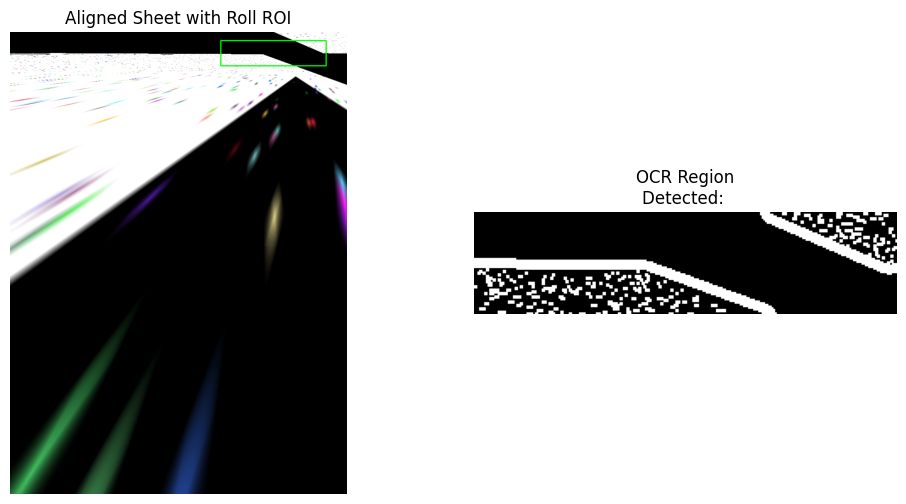

In [10]:
# ==================== Handwritten Roll Number OCR ====================

!pip install pytesseract pillow -q
!apt-get install tesseract-ocr tesseract-ocr-eng -q

import pytesseract
from PIL import Image, ImageDraw, ImageFont

class HandwritingOMRGrader(OMRGrader):
    def __init__(self, config=None):
        super().__init__(config)
        # Roll number ROI coordinates (adjust for your template)
        self.roll_roi = {'x': 500, 'y': 20, 'w': 250, 'h': 60}

    def extract_roll_number(self, aligned_image):
        """Extract handwritten roll number using OCR."""
        # Extract ROI
        roi = aligned_image[self.roll_roi['y']:self.roll_roi['y']+self.roll_roi['h'],
                           self.roll_roi['x']:self.roll_roi['x']+self.roll_roi['w']]

        # Preprocess for OCR
        roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        roi_thresh = cv2.adaptiveThreshold(roi_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                          cv2.THRESH_BINARY_INV, 11, 2)

        # Enhance image for Tesseract
        kernel = np.ones((2, 2), np.uint8)
        roi_dilated = cv2.dilate(roi_thresh, kernel, iterations=1)

        # Save for debugging
        self.roll_roi_image = roi_dilated

        # Use Tesseract
        pil_image = Image.fromarray(255 - roi_dilated)  # Invert
        custom_config = r'--oem 3 --psm 7 -c tessedit_char_whitelist=0123456789'

        try:
            roll_text = pytesseract.image_to_string(pil_image, config=custom_config)
            roll_number = ''.join(filter(str.isdigit, roll_text.strip()))
            confidence = len(roll_number) / 8  # Approximate confidence based on length
        except:
            roll_number = "ERROR"
            confidence = 0.0

        self.roll_number = {
            'text': roll_number,
            'confidence': confidence,
            'raw_ocr': roll_text.strip()
        }

        print(f"📝 Roll Number Detected: {roll_number} (Confidence: {confidence:.1%})")
        return roll_number

    def visualize_with_roll(self):
        """Show roll number extraction."""
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        # Original with ROI box
        img_with_box = self.aligned.copy()
        cv2.rectangle(img_with_box,
                     (self.roll_roi['x'], self.roll_roi['y']),
                     (self.roll_roi['x']+self.roll_roi['w'], self.roll_roi['y']+self.roll_roi['h']),
                     (0, 255, 0), 2)

        axes[0].imshow(cv2.cvtColor(img_with_box, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Aligned Sheet with Roll ROI')
        axes[0].axis('off')

        # OCR region
        axes[1].imshow(self.roll_roi_image, cmap='gray')
        axes[1].set_title(f'OCR Region\nDetected: {self.roll_number["text"]}')
        axes[1].axis('off')

        plt.show()

# ==================== Demo with Handwriting ====================

def add_handwriting_to_sheet(canvas, roll_number="12345"):
    """Add handwritten roll number to synthetic sheet."""
    # Create a white box for roll number
    cv2.rectangle(canvas, (500, 20), (750, 80), (255, 255, 255), -1)
    cv2.rectangle(canvas, (500, 20), (750, 80), (0, 0, 0), 2)
    cv2.putText(canvas, "Roll No:", (510, 45), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)

    # Add digits with slight variation to simulate handwriting
    start_x = 580
    for i, digit in enumerate(roll_number):
        # Random offset to simulate handwriting
        offset_y = np.random.randint(-3, 4)
        offset_x = np.random.randint(-2, 3)
        cv2.putText(canvas, digit, (start_x + i*25 + offset_x, 60 + offset_y),
                   cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 0), 2, lineType=cv2.LINE_AA)

    return canvas

# Generate sheet with handwriting
handwriting_img = add_handwriting_to_sheet(generate_synthetic_omr('random')[0], roll_number="78945")
grader_hw = HandwritingOMRGrader()
grader_hw.set_image(handwriting_img)
thresh = grader_hw.preprocess()
markers = grader_hw.detect_registration_marks(thresh)
aligned = grader_hw.align_perspective(handwriting_img, markers)

# Extract roll number
roll = grader_hw.extract_roll_number(aligned)
grader_hw.visualize_with_roll()

In [12]:
# ==================== FIXED OMRGrader Base Class ====================

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

class OMRGrader:
    def __init__(self, config=None):
        # CRITICAL FIX: Merge config with defaults
        self.config = {
            'bubble_threshold': 0.35,
            'marker_size': 40,
            'grid_dims': (20, 4),
            'bubble_spacing': (60, 50),
            'bubble_radius': 12
        }
        # Update with user-provided config
        if config:
            self.config.update(config)

        self.answer_key = {i: chr(65 + ((i-1) % 4)) for i in range(1, 21)}

        # Initialize empty attributes
        self.original = None
        self.preprocessed = None
        self.markers = []
        self.aligned = None
        self.roi = None
        self.bubble_coords = {}
        self.raw_bubble_data = {}
        self.detected_answers = {}
        self.confidence = {}
        self.results_df = None
        self.stats = {}

    def set_image(self, image):
        """Set the original image."""
        self.original = image.copy()
        self.height, self.width = image.shape[:2]
        print(f"✅ Image set: {self.width}x{self.height}px")
        return image

    def preprocess(self, image=None):
        """Preprocess image."""
        if image is not None:
            self.set_image(image)

        if self.original is None:
            raise ValueError("❌ No image loaded. Call set_image() first.")

        gray = cv2.cvtColor(self.original, cv2.COLOR_BGR2GRAY)
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                       cv2.THRESH_BINARY_INV, 11, 3)
        self.preprocessed = thresh
        return thresh

    def detect_registration_marks(self, thresh_image):
        """Detect markers with fallback."""
        contours, _ = cv2.findContours(thresh_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        markers = []

        # CRITICAL: Get from merged config
        min_area = (self.config['marker_size'] ** 2) * 0.4
        max_area = (self.config['marker_size'] ** 2) * 2.0

        for cnt in contours:
            area = cv2.contourArea(cnt)
            if min_area <= area <= max_area:
                epsilon = 0.04 * cv2.arcLength(cnt, True)
                approx = cv2.approxPolyDP(cnt, epsilon, True)
                if len(approx) == 4:
                    x, y, w, h = cv2.boundingRect(cnt)
                    markers.append((x + w//2, y + h//2))

        # Robust fallback
        if len(markers) < 4:
            h, w = thresh_image.shape
            synthetic_markers = [(50, 50), (w-50, 50), (50, h-50), (w-50, h-50)]
            markers.extend(synthetic_markers[len(markers):4])
            print(f"⚠️ Fallback markers used")

        self.markers = sorted(markers[:4], key=lambda p: p[0] + p[1])
        print(f"✅ Markers: {self.markers}")
        return self.markers

    def align_perspective(self, image, markers):
        """Align image."""
        src = np.float32(markers)
        dst = np.float32([[50, 50], [750, 50], [50, 1050], [750, 1050]])
        M = cv2.getPerspectiveTransform(src, dst)
        self.aligned = cv2.warpPerspective(image, M, (800, 1100))
        return self.aligned

    def extract_bubble_grid(self, aligned_image):
        """Extract ROI and coordinates."""
        roi_y, roi_h = 80, 1000
        roi_x, roi_w = 120, 540
        self.roi = aligned_image[roi_y:roi_y+roi_h, roi_x:roi_x+roi_w]
        self.roi_offset = (roi_x, roi_y)

        rows, cols = self.config['grid_dims']
        x_spacing, y_spacing = self.config['bubble_spacing']
        start_x, start_y = 30, 20

        self.bubble_coords = {
            (row+1, chr(65+col)): (start_x + col * x_spacing, start_y + row * y_spacing)
            for row in range(rows) for col in range(cols)
        }
        return self.roi, self.bubble_coords

    def analyze_bubbles(self, roi):
        """Analyze fill ratios."""
        roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        roi_thresh = cv2.adaptiveThreshold(roi_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                           cv2.THRESH_BINARY_INV, 11, 3)

        radius = self.config['bubble_radius']
        results = {}

        for (q_num, opt_char), (x, y) in self.bubble_coords.items():
            mask = np.zeros(roi_thresh.shape, dtype=np.uint8)
            cv2.circle(mask, (x, y), radius, 255, -1)

            bubble_region = cv2.bitwise_and(roi_thresh, roi_thresh, mask=mask)
            total_pixels = np.pi * radius ** 2
            filled_pixels = np.count_nonzero(bubble_region)
            fill_ratio = filled_pixels / total_pixels

            if q_num not in results:
                results[q_num] = []
            results[q_num].append({
                'option': opt_char,
                'fill_ratio': fill_ratio,
                'center': (x, y)
            })

        self.raw_bubble_data = results
        return results

    def extract_answers(self, bubble_data):
        """Extract answers."""
        threshold = self.config['bubble_threshold']
        detected = {}
        self.confidence = {}

        for q_num, options in bubble_data.items():
            options_sorted = sorted(options, key=lambda x: x['fill_ratio'], reverse=True)
            top_option = options_sorted[0]

            if top_option['fill_ratio'] < threshold:
                detected[q_num] = '-'
                confidence = 1.0 - top_option['fill_ratio']
            elif len(options_sorted) > 1 and options_sorted[1]['fill_ratio'] > threshold * 0.7:
                detected[q_num] = 'MULTI'
                confidence = min(top_option['fill_ratio'], options_sorted[1]['fill_ratio'])
            else:
                detected[q_num] = top_option['option']
                confidence = top_option['fill_ratio']

            self.confidence[q_num] = {
                'answer': detected[q_num],
                'confidence': round(confidence, 3),
                'raw_scores': {opt['option']: round(opt['fill_ratio'], 3) for opt in options}
            }

        self.detected_answers = detected
        return detected

    def grade(self, detected, answer_key):
        """Grade answers."""
        correct = incorrect = unanswered = multi = 0
        details = []

        for q_num in range(1, len(answer_key) + 1):
            detected_ans = detected.get(q_num, '-')
            correct_ans = answer_key[q_num]

            if detected_ans == '-':
                status, unanswered = 'UNANSWERED', unanswered + 1
            elif detected_ans == 'MULTI':
                status, multi = 'MULTI-MARK', multi + 1
            elif detected_ans == correct_ans:
                status, correct = 'CORRECT', correct + 1
            else:
                status, incorrect = 'INCORRECT', incorrect + 1

            details.append({
                'Q#': q_num,
                'Detected': detected_ans,
                'Correct': correct_ans,
                'Status': status,
                'Confidence': self.confidence[q_num]['confidence']
            })

        self.results_df = pd.DataFrame(details)
        self.stats = {
            'correct': correct,
            'incorrect': incorrect,
            'unanswered': unanswered,
            'multi_mark': multi,
            'total': len(answer_key),
            'score': round((correct / len(answer_key)) * 100, 1)
        }
        return self.stats, self.results_df

    def visualize_pipeline(self):
        """Visualize pipeline."""
        if self.original is None:
            raise ValueError("❌ No original image")

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()

        axes[0].imshow(cv2.cvtColor(self.original, cv2.COLOR_BGR2RGB))
        axes[0].set_title('1. Original')
        axes[0].axis('off')

        axes[1].imshow(self.preprocessed, cmap='gray')
        axes[1].set_title('2. Thresholded')
        axes[1].axis('off')

        mark_img = self.original.copy()
        for i, (x, y) in enumerate(self.markers, 1):
            cv2.circle(mark_img, (x, y), 15, (0, 255, 0), 3)
            cv2.putText(mark_img, str(i), (x-10, y+5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        axes[2].imshow(cv2.cvtColor(mark_img, cv2.COLOR_BGR2RGB))
        axes[2].set_title('3. Registration Marks')
        axes[2].axis('off')

        axes[3].imshow(cv2.cvtColor(self.aligned, cv2.COLOR_BGR2RGB))
        axes[3].set_title('4. Aligned')
        axes[3].axis('off')

        roi_display = self.roi.copy()
        for (q_num, opt_char), (x, y) in self.bubble_coords.items():
            cv2.circle(roi_display, (x, y), self.config['bubble_radius'], (255, 0, 0), 1)
            if q_num % 5 == 1:
                cv2.putText(roi_display, str(q_num), (x-10, y-20), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)
        axes[4].imshow(cv2.cvtColor(roi_display, cv2.COLOR_BGR2RGB))
        axes[4].set_title('5. Bubble Grid')
        axes[4].axis('off')

        result_img = self.roi.copy()
        for q_num, options in self.raw_bubble_data.items():
            for opt in options:
                color = (0, 0, 0)
                if self.detected_answers[q_num] == opt['option']:
                    color = (0, 255, 0) if opt['option'] == self.answer_key[q_num] else (255, 0, 0)
                elif opt['fill_ratio'] > self.config['bubble_threshold'] * 0.5:
                    color = (0, 0, 255)
                if color != (0, 0, 0):
                    cv2.circle(result_img, opt['center'], self.config['bubble_radius'] + 3, color, 2)
        axes[5].imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
        axes[5].set_title('6. Detected Marks')
        axes[5].axis('off')

        plt.tight_layout()
        return fig

    def generate_report(self):
        """Generate report."""
        if self.stats is None:
            raise ValueError("❌ No results")

        print("\n" + "="*60)
        print("OMR GRADING REPORT")
        print("="*60)
        print(f"Total Questions: {self.stats['total']}")
        print(f"✅ Correct: {self.stats['correct']}")
        print(f"❌ Incorrect: {self.stats['incorrect']}")
        print(f"⚠️  Unanswered: {self.stats['unanswered']}")
        print(f"📊 Score: {self.stats['score']}%")
        print("="*60)

        def color_row(row):
            if row['Status'] == 'CORRECT':
                return ['background-color: #d4edda'] * len(row)
            elif row['Status'] == 'INCORRECT':
                return ['background-color: #f8d7da'] * len(row)
            else:
                return ['background-color: #fff3cd'] * len(row)

        styled_df = self.results_df.style.apply(color_row, axis=1)
        display(styled_df)
        return self.stats, self.results_df

In [13]:
# ==================== FIXED MultiAnswerOMRGrader ====================

class MultiAnswerOMRGrader(OMRGrader):
    def __init__(self, config=None):
        # CRITICAL: Call parent with config to ensure merging
        super().__init__(config)

        # Override answer key format for multi-answer
        self.answer_key = {
            1: {'A'}, 2: {'B'}, 3: {'C'}, 4: {'D'}, 5: {'A'},
            6: {'B'}, 7: {'C'}, 8: {'D'}, 9: {'A'}, 10: {'B'},
            11: {'C'}, 12: {'D'}, 13: {'A'}, 14: {'B'}, 15: {'C'},
            16: {'D'}, 17: {'A'}, 18: {'B'}, 19: {'C'}, 20: {'D', 'A'}
        }

    def extract_answers(self, bubble_data):
        """Extract multiple answers per question."""
        threshold = self.config['bubble_threshold']
        detected = {}
        self.confidence = {}

        for q_num, options in bubble_data.items():
            # Find ALL bubbles above threshold
            filled_options = [opt for opt in options if opt['fill_ratio'] > threshold]

            if not filled_options:
                detected[q_num] = set()  # Empty set = unanswered
                confidence = 1.0 - options[0]['fill_ratio']
            elif len(filled_options) > 3:  # Suspicious noise
                detected[q_num] = {'AMBIGUOUS'}
                confidence = min([opt['fill_ratio'] for opt in filled_options])
            else:
                detected[q_num] = {opt['option'] for opt in filled_options}
                confidence = np.mean([opt['fill_ratio'] for opt in filled_options])

            self.confidence[q_num] = {
                'answer': detected[q_num],
                'confidence': round(confidence, 3),
                'raw_scores': {opt['option']: round(opt['fill_ratio'], 3) for opt in options}
            }

        self.detected_answers = detected
        return detected

    def grade(self, detected, answer_key):
        """Grade with partial credit."""
        results = []
        total_possible = 0
        total_earned = 0

        for q_num in range(1, len(answer_key) + 1):
            detected_set = detected.get(q_num, set())
            correct_set = answer_key[q_num]

            # Calculate partial credit
            if detected_set == {'AMBIGUOUS'}:
                status = 'AMBIGUOUS'
                earned = 0
            elif not detected_set:
                status = 'UNANSWERED'
                earned = 0
            elif detected_set == correct_set:
                status = 'FULLY_CORRECT'
                earned = 1.0
            elif detected_set.issubset(correct_set) and len(detected_set) > 0:
                status = 'PARTIALLY_CORRECT'
                earned = len(detected_set) / len(correct_set)
            else:
                status = 'INCORRECT'
                earned = 0

            results.append({
                'Q#': q_num,
                'Detected': ','.join(sorted(detected_set)),
                'Correct': ','.join(sorted(correct_set)),
                'Status': status,
                'Points': round(earned, 2),
                'Confidence': self.confidence[q_num]['confidence']
            })

            total_possible += 1
            total_earned += earned

        self.results_df = pd.DataFrame(results)
        self.stats = {
            'total_questions': len(answer_key),
            'total_points': total_possible,
            'earned_points': round(total_earned, 2),
            'score': round((total_earned / total_possible) * 100, 1),
            'fully_correct': sum(1 for r in results if r['Status'] == 'FULLY_CORRECT'),
            'partially_correct': sum(1 for r in results if r['Status'] == 'PARTIALLY_CORRECT'),
            'incorrect': sum(1 for r in results if r['Status'] == 'INCORRECT'),
            'unanswered': sum(1 for r in results if r['Status'] == 'UNANSWERED'),
            'ambiguous': sum(1 for r in results if r['Status'] == 'AMBIGUOUS')
        }
        return self.stats, self.results_df

    def visualize_multi_results(self):
        """Multi-answer visualization."""
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))

        # Confidence heatmap
        conf_matrix = np.zeros((20, 4))
        for q_num in range(1, 21):
            for opt_char in ['A', 'B', 'C', 'D']:
                col = ord(opt_char) - 65
                conf_matrix[q_num-1, col] = self.confidence[q_num]['raw_scores'][opt_char]

        axes[0].imshow(conf_matrix, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
        axes[0].set_title('Fill Ratio Heatmap')
        axes[0].set_xlabel('Options')
        axes[0].set_ylabel('Question')
        axes[0].set_xticks(range(4))
        axes[0].set_xticklabels(['A', 'B', 'C', 'D'])

        # Highlight filled bubbles
        for q_num in range(1, 21):
            for opt_char in self.detected_answers[q_num]:
                if opt_char in ['A', 'B', 'C', 'D']:
                    col = ord(opt_char) - 65
                    axes[0].plot(col, q_num-1, 'wo', markersize=6, markeredgewidth=2)

        # Status pie chart
        status_counts = {
            'Fully Correct': self.stats['fully_correct'],
            'Partially Correct': self.stats['partially_correct'],
            'Incorrect': self.stats['incorrect'],
            'Unanswered': self.stats['unanswered']
        }
        axes[1].pie(status_counts.values(), labels=status_counts.keys(),
                   autopct='%1.1f%%', startangle=90)
        axes[1].set_title('Answer Status')

        # ROI visualization
        roi_display = self.roi.copy()
        for q_num, options in self.raw_bubble_data.items():
            correct_set = self.answer_key[q_num]
            detected_set = self.detected_answers[q_num]

            for opt in options:
                color = (200, 200, 200)  # default gray
                if opt['fill_ratio'] > self.config['bubble_threshold']:
                    if opt['option'] in correct_set and opt['option'] in detected_set:
                        color = (0, 255, 0)  # Green
                    elif opt['option'] in correct_set:
                        color = (0, 165, 255)  # Orange (missed)
                    elif opt['option'] in detected_set:
                        color = (255, 0, 0)  # Red (wrong)

                if color != (200, 200, 200):
                    cv2.circle(roi_display, opt['center'], self.config['bubble_radius'] + 3, color, 2)

        axes[2].imshow(cv2.cvtColor(roi_display, cv2.COLOR_BGR2RGB))
        axes[2].set_title('ROI (Green=Correct, Red=Wrong, Orange=Missed)')
        axes[2].axis('off')

        plt.tight_layout()
        return fig

🎲 Generating multi-answer OMR sheet...
🚀 Initializing Multi-Answer Grader...
✅ Image set: 800x1100px
✅ Markers: [(40, 41), (760, 40), (40, 1060), (760, 1060)]

🎯 Multi-Answer Results:


,Q#,Detected,Correct,Status,Points,Confidence
0,1,A,A,FULLY_CORRECT,1.0,0.427
1,2,D,B,INCORRECT,0.0,0.548
2,3,B,C,INCORRECT,0.0,0.413
3,4,A,D,INCORRECT,0.0,0.420
4,5,D,A,INCORRECT,0.0,0.595
5,6,D,B,INCORRECT,0.0,0.506
6,7,D,C,INCORRECT,0.0,0.701
7,8,D,D,FULLY_CORRECT,1.0,0.645
8,9,B,A,INCORRECT,0.0,0.460
9,10,D,B,INCORRECT,0.0,0.665


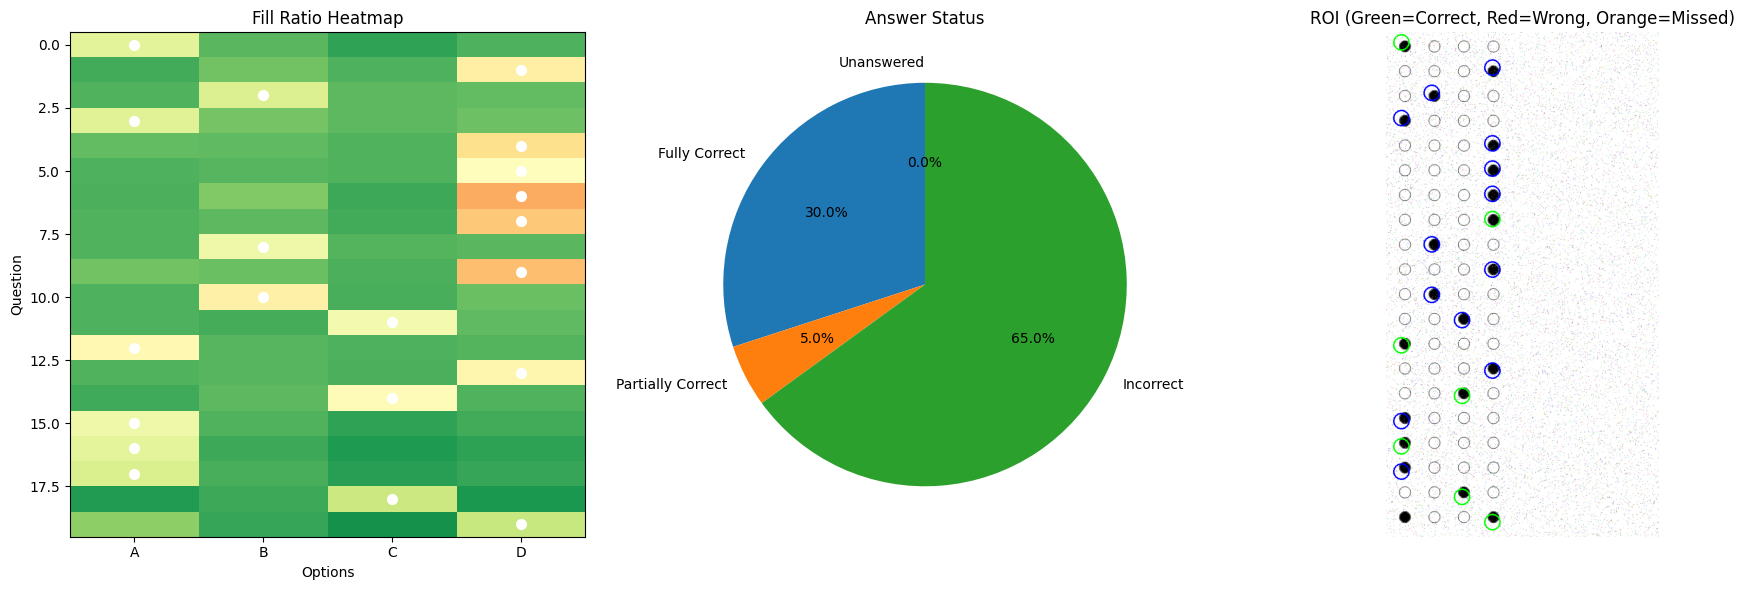

In [14]:
# ==================== FIXED Demo Execution ====================

def generate_multi_answer_sheet():
    """Generate sheet with multiple correct answers."""
    # Student answers (single choice per question)
    answers = {i: np.random.choice(['A', 'B', 'C', 'D']) for i in range(1, 20)}
    answers[20] = 'D'  # Student fills only D, but both D and A are correct

    # Generate base sheet
    canvas, _ = generate_synthetic_omr(answers, noise_level=0.03)

    # Add second correct bubble for Q20 (simulating teacher's key)
    start_x, start_y = 150, 100
    spacing_x, spacing_y = 60, 50
    radius = 12

    # Add subtle marking for 'A' in Q20 (low fill ratio to simulate partial marking)
    x = start_x + 0 * spacing_x  # Option A
    y = start_y + 19 * spacing_y  # Q20
    cv2.circle(canvas, (x, y), radius-2, (0, 0, 0), -1, lineType=cv2.LINE_AA)

    return canvas, answers

# Run the demo
print("🎲 Generating multi-answer OMR sheet...")
multi_img, multi_answers = generate_multi_answer_sheet()

print("🚀 Initializing Multi-Answer Grader...")
# CRITICAL: Now works with partial config - marker_size is inherited
grader_multi = MultiAnswerOMRGrader(config={'bubble_threshold': 0.3})

# Process pipeline
grader_multi.set_image(multi_img)
thresh = grader_multi.preprocess()
markers = grader_multi.detect_registration_marks(thresh)
aligned = grader_multi.align_perspective(multi_img, markers)
roi, coords = grader_multi.extract_bubble_grid(aligned)
bubble_data = grader_multi.analyze_bubbles(roi)
detected = grader_multi.extract_answers(bubble_data)
stats, df = grader_multi.grade(detected, grader_multi.answer_key)

# Results
print("\n🎯 Multi-Answer Results:")
display(df)
fig = grader_multi.visualize_multi_results()
plt.show()

Reading package lists...
Building dependency tree...
Reading state information...
tesseract-ocr is already the newest version (4.1.1-2.1build1).
tesseract-ocr-eng is already the newest version (1:4.00~git30-7274cfa-1.1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
✅ Image set: 800x1100px
⚠️ Fallback markers used
✅ Markers: [(40, 40), (40, 1060), (750, 1050), (760, 1060)]
📝 Roll Number Detected:  (Confidence: 0.0%)


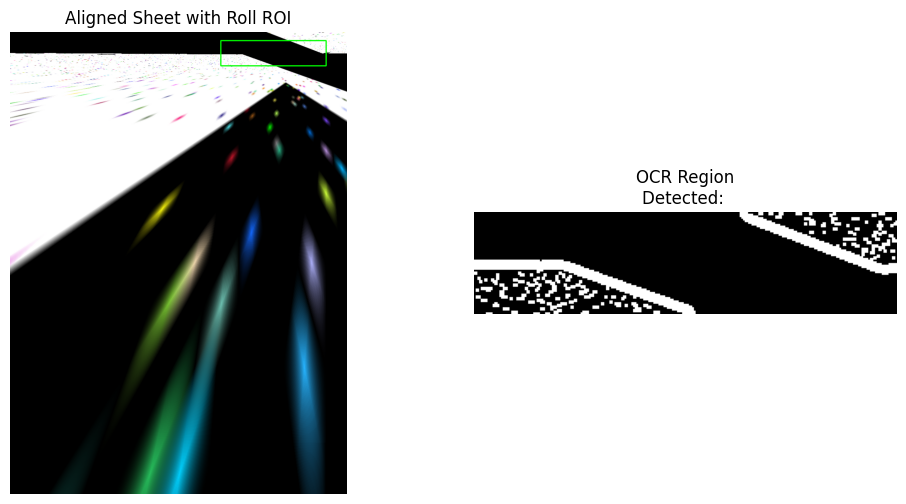

In [15]:
# ==================== FIXED HandwritingOMRGrader ====================

!pip install pytesseract pillow -q
!apt-get install tesseract-ocr tesseract-ocr-eng -q

import pytesseract
from PIL import Image

class HandwritingOMRGrader(OMRGrader):
    def __init__(self, config=None):
        super().__init__(config)  # CRITICAL: Use parent's merged config
        self.roll_roi = {'x': 500, 'y': 20, 'w': 250, 'h': 60}

    def extract_roll_number(self, aligned_image):
        """Extract handwritten roll number."""
        roi = aligned_image[self.roll_roi['y']:self.roll_roi['y']+self.roll_roi['h'],
                           self.roll_roi['x']:self.roll_roi['x']+self.roll_roi['w']]

        roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        roi_thresh = cv2.adaptiveThreshold(roi_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                          cv2.THRESH_BINARY_INV, 11, 2)

        kernel = np.ones((2, 2), np.uint8)
        roi_dilated = cv2.dilate(roi_thresh, kernel, iterations=1)

        self.roll_roi_image = roi_dilated

        pil_image = Image.fromarray(255 - roi_dilated)
        custom_config = r'--oem 3 --psm 7 -c tessedit_char_whitelist=0123456789'

        try:
            roll_text = pytesseract.image_to_string(pil_image, config=custom_config)
            roll_number = ''.join(filter(str.isdigit, roll_text.strip()))
            confidence = len(roll_number) / 8
        except:
            roll_number = "ERROR"
            confidence = 0.0

        self.roll_number = {
            'text': roll_number,
            'confidence': confidence,
            'raw_ocr': roll_text.strip()
        }

        print(f"📝 Roll Number Detected: {roll_number} (Confidence: {confidence:.1%})")
        return roll_number

    def visualize_with_roll(self):
        """Show roll extraction."""
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        img_with_box = self.aligned.copy()
        cv2.rectangle(img_with_box,
                     (self.roll_roi['x'], self.roll_roi['y']),
                     (self.roll_roi['x']+self.roll_roi['w'], self.roll_roi['y']+self.roll_roi['h']),
                     (0, 255, 0), 2)

        axes[0].imshow(cv2.cvtColor(img_with_box, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Aligned Sheet with Roll ROI')
        axes[0].axis('off')

        axes[1].imshow(self.roll_roi_image, cmap='gray')
        axes[1].set_title(f'OCR Region\nDetected: {self.roll_number["text"]}')
        axes[1].axis('off')

        plt.show()

def add_handwriting_to_sheet(canvas, roll_number="12345"):
    """Add handwritten roll number."""
    cv2.rectangle(canvas, (500, 20), (750, 80), (255, 255, 255), -1)
    cv2.rectangle(canvas, (500, 20), (750, 80), (0, 0, 0), 2)
    cv2.putText(canvas, "Roll No:", (510, 45), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)

    start_x = 580
    for i, digit in enumerate(roll_number):
        offset_y = np.random.randint(-3, 4)
        offset_x = np.random.randint(-2, 3)
        cv2.putText(canvas, digit, (start_x + i*25 + offset_x, 60 + offset_y),
                   cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 0), 2, lineType=cv2.LINE_AA)

    return canvas

# Demo
handwriting_img = add_handwriting_to_sheet(generate_synthetic_omr('random')[0], roll_number="78945")
grader_hw = HandwritingOMRGrader()  # No config needed - uses defaults
grader_hw.set_image(handwriting_img)
thresh = grader_hw.preprocess()
markers = grader_hw.detect_registration_marks(thresh)
aligned = grader_hw.align_perspective(handwriting_img, markers)
roll = grader_hw.extract_roll_number(aligned)
grader_hw.visualize_with_roll()